1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Euclidean Distance: 0.0000


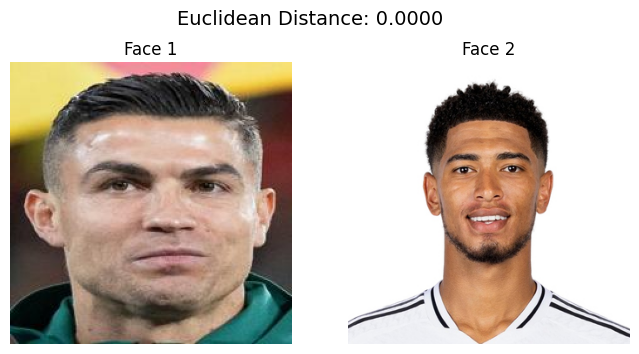

In [9]:
# =============================
# Face Comparison / Matching using FaceNet
# =============================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras_facenet import FaceNet

# =============================
# 1️⃣ Initialize FaceNet Embedder
# =============================
embedder = FaceNet()  # pre-trained FaceNet model

# =============================
# 2️⃣ Face Preprocessing
# =============================
def preprocess_face(img_path, required_size=(160,160)):
    """
    Input: Image path
    Output: Preprocessed face ready for FaceNet (160x160, normalized)
    """
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, required_size)
    img = img.astype('float32')
    
    # Standardization (mean 0, std 1)
    mean, std = img.mean(), img.std()
    img = (img - mean) / std
    return img

# =============================
# 3️⃣ Get Embedding from FaceNet
# =============================
def get_embedding(face_img):
    """
    Input: Preprocessed face image
    Output: 512D embedding vector
    """
    face_img = np.expand_dims(face_img, axis=0)  # shape: (1,160,160,3)
    embedding = embedder.embeddings(face_img)
    return embedding[0]

# =============================
# 4️⃣ Euclidean Distance
# =============================
def euclidean_distance(vec1, vec2):
    """
    Input: Two 512D embedding vectors
    Output: Euclidean distance
    """
    return np.linalg.norm(vec1 - vec2)

# =============================
# 5️⃣ Load Images and Extract Embeddings
# =============================
img1_path = 'dataset/train/ronaldo/6.jpg'         # Example known image
img2_path = 'dataset/test/bellingham/bellingham.jpg'  # Example test image

# Preprocess images
face1 = preprocess_face(img1_path)
face2 = preprocess_face(img2_path)

# Get embeddings
embedding1 = get_embedding(face1)
embedding2 = get_embedding(face2)

# Compute Euclidean distance
distance = euclidean_distance(embedding1, embedding2)
print(f"Euclidean Distance: {distance:.4f}")

# =============================
# 6️⃣ Visualization with Matplotlib
# =============================
img1_disp = cv2.cvtColor(cv2.imread(img1_path), cv2.COLOR_BGR2RGB)
img2_disp = cv2.cvtColor(cv2.imread(img2_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1_disp)
plt.axis('off')
plt.title('Face 1')

plt.subplot(1,2,2)
plt.imshow(img2_disp)
plt.axis('off')
plt.title('Face 2')

plt.suptitle(f'Euclidean Distance: {distance:.4f}', fontsize=14)
plt.show()